In [3]:
!pip install GraphRicciCurvature --quiet

In [49]:
import networkx as nx
import matplotlib.pyplot as plt

from GraphRicciCurvature.OllivierRicci import OllivierRicci
from GraphRicciCurvature.FormanRicci import FormanRicci

from sklearn import preprocessing, metrics

## Curvatura de Ricci discreta
La curvatura es una propiedad geométrica para describir la forma local de un objeto. En el grafo, una arista con *curvatura positiva* representa una arista **dentro de un clúster**, mientras que una arista con *curvatura negativa* tiende a ser un **puente** entre clústeres.

Actualmente, existen múltiples formas de discretizar la curvatura en un grafo; entre ellas:

- **Curvatura de Ollivier-Ricci**: Curvatura basada en la teoría del transporte óptimo. Proporciona una visión micro de la curvatura para cada arista, pero es computacionalmente más pesada.
- **Curvatura de Forman-Ricci**: Curvatura basada en complejos CW. Proporciona una visión macro de la curvatura para cada arista con una velocidad de cómputo súper ligera.

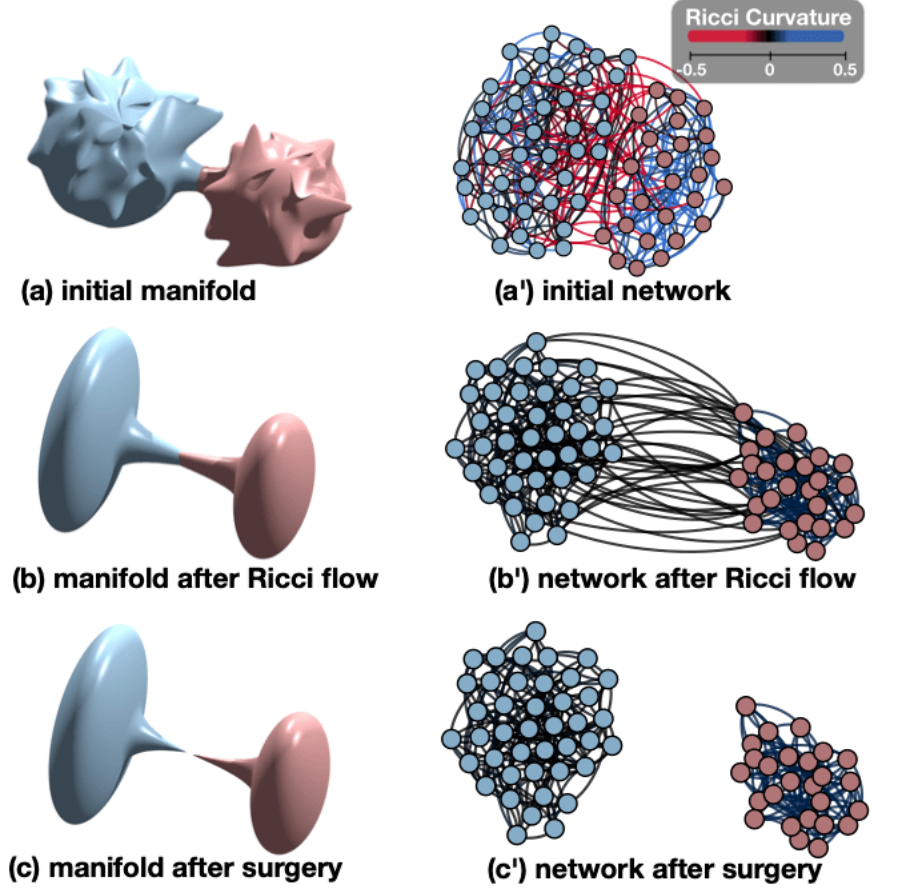

# [Curvatura de Ricci](https://arxiv.org/pdf/1501.04138)

In [17]:
G = nx.karate_club_graph()
for (n1, n2, d) in G.edges(data=True):
    d.clear()   #quitar pesos
print(G)

Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


Al comparar dos vecindarios, se asume que el $\alpha$% de la masa se queda quieta en el nodo original y el otro ($1- \alpha$)% se distribuye entre sus vecinos

`compute_ricci_curvature` Recorre cada una de las aristas del grafo, resuelve el problema de transporte óptimo entre los vecindarios de los dos nodos que conecta, y obtiene el número final. Automáticamente inyecta este valor como un atributo dentro de las aristas del grafo original.

In [22]:
orc = OllivierRicci(G, alpha=0.5, verbose="TRACE")
orc.compute_ricci_curvature()
G_orc = orc.G.copy()

INFO:GraphRicciCurvature:Edge weight not detected in graph, use "weight" as default edge weight.
TRACE:GraphRicciCurvature:Number of nodes: 34
TRACE:GraphRicciCurvature:Number of edges: 78
TRACE:GraphRicciCurvature:Start to compute all pair shortest path.
TRACE:GraphRicciCurvature:0.003163 secs for all pair by NetworKit.
INFO:GraphRicciCurvature:0.088676 secs for Ricci curvature computation.


In [26]:
G.edges(data=True)

EdgeDataView([(0, 1, {}), (0, 2, {}), (0, 3, {}), (0, 4, {}), (0, 5, {}), (0, 6, {}), (0, 7, {}), (0, 8, {}), (0, 10, {}), (0, 11, {}), (0, 12, {}), (0, 13, {}), (0, 17, {}), (0, 19, {}), (0, 21, {}), (0, 31, {}), (1, 2, {}), (1, 3, {}), (1, 7, {}), (1, 13, {}), (1, 17, {}), (1, 19, {}), (1, 21, {}), (1, 30, {}), (2, 3, {}), (2, 7, {}), (2, 8, {}), (2, 9, {}), (2, 13, {}), (2, 27, {}), (2, 28, {}), (2, 32, {}), (3, 7, {}), (3, 12, {}), (3, 13, {}), (4, 6, {}), (4, 10, {}), (5, 6, {}), (5, 10, {}), (5, 16, {}), (6, 16, {}), (8, 30, {}), (8, 32, {}), (8, 33, {}), (9, 33, {}), (13, 33, {}), (14, 32, {}), (14, 33, {}), (15, 32, {}), (15, 33, {}), (18, 32, {}), (18, 33, {}), (19, 33, {}), (20, 32, {}), (20, 33, {}), (22, 32, {}), (22, 33, {}), (23, 25, {}), (23, 27, {}), (23, 29, {}), (23, 32, {}), (23, 33, {}), (24, 25, {}), (24, 27, {}), (24, 31, {}), (25, 31, {}), (26, 29, {}), (26, 33, {}), (27, 33, {}), (28, 31, {}), (28, 33, {}), (29, 32, {}), (29, 33, {}), (30, 32, {}), (30, 33, {}),

In [25]:
G_orc.edges(data=True)

EdgeDataView([(0, 1, {'weight': 1.0, 'ricciCurvature': 0.11111111111111094}), (0, 2, {'weight': 1.0, 'ricciCurvature': -0.14375000000000004}), (0, 3, {'weight': 1.0, 'ricciCurvature': 0.04166666666666674}), (0, 4, {'weight': 1.0, 'ricciCurvature': -0.11458333333333326}), (0, 5, {'weight': 1.0, 'ricciCurvature': -0.28125}), (0, 6, {'weight': 1.0, 'ricciCurvature': -0.28125}), (0, 7, {'weight': 1.0, 'ricciCurvature': 0.0625}), (0, 8, {'weight': 1.0, 'ricciCurvature': -0.19999999999999996}), (0, 10, {'weight': 1.0, 'ricciCurvature': -0.11458333333333326}), (0, 11, {'weight': 1.0, 'ricciCurvature': 0.0625}), (0, 12, {'weight': 1.0, 'ricciCurvature': 0.0}), (0, 13, {'weight': 1.0, 'ricciCurvature': 0.06249999999999989}), (0, 17, {'weight': 1.0, 'ricciCurvature': 0.0625}), (0, 19, {'weight': 1.0, 'ricciCurvature': -0.03125000000000022}), (0, 21, {'weight': 1.0, 'ricciCurvature': 0.0625}), (0, 31, {'weight': 1.0, 'ricciCurvature': -0.4270833333333335}), (1, 2, {'weight': 1.0, 'ricciCurvature'

Grafiquemos el histograma de las distribuciones de la curvatura de Ricci en las aristas.

En la mayoría de los casos, las curvaturas de Ollivier-Ricci se encuentran en el rango de [-1, 1].

Se ha demostrado que las distribuciones de la curvatura de Ricci varían de un grafo a otro, por lo que pueden actuar como una huella digital del grafo (*graph fingerprint*) o un *graph kernel*.

Red del Karate Club, primeros 5 enlaces: 
La curvatura de Ricci del enlace (0,1) es 0.111111
La curvatura de Ricci del enlace (0,2) es -0.143750
La curvatura de Ricci del enlace (0,3) es 0.041667
La curvatura de Ricci del enlace (0,4) es -0.114583
La curvatura de Ricci del enlace (0,5) es -0.281250


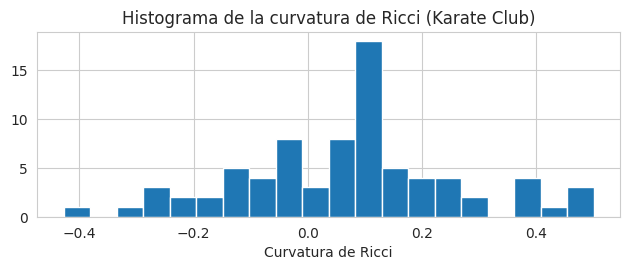

In [31]:
def show_results(G, curvature="ricciCurvature"):

    print("Red del Karate Club, primeros 5 enlaces: ")
    for n1,n2 in list(G.edges())[:5]:
        print("La curvatura de Ricci del enlace (%s,%s) es %f" % (n1 ,n2, G[n1][n2][curvature]))

    #Histograma
    plt.subplot(2, 1, 1)
    ricci_curvtures = nx.get_edge_attributes(G, curvature).values()
    plt.hist(ricci_curvtures,bins=20)
    plt.xlabel('Curvatura de Ricci')
    plt.title("Histograma de la curvatura de Ricci (Karate Club)")

    plt.tight_layout()

show_results(G_orc)

# Flujo de Ricci

Es un proceso iterativo que tiene como objetivo *suavizar las curvaturas de una red* ajustando el peso de las aristas; con el tiempo, **estira** las aristas con curvatura de Ricci muy **negativa** y **encoge** las aristas con curvatura de Ricci muy **positiva**.

Para calcular el flujo de Ollivier-Ricci, simplemente llama a la función `compute_ricci_flow` para iniciar el proceso.

`alpha=0.5`: La "pereza" del transporte óptimo.

`base=1` y `exp_power=0`: Parámetros específicos para usar la dist. de probabilidad de Lin-Yau (una variante para calcular la masa en los nodos). Configuran cómo decae la probabilidad al alejarse de un nodo.

`proc=4`: El transporte óptimo es pesado computacionalmente. Le dice a Python que use 4 núcleos del procesador para calcular en paralelo.

In [36]:
orf = OllivierRicci(G, alpha=0.5, base=1, exp_power=0, proc=4, verbose="INFO")

#2 iteraciones del flujo de Ricci
#Mide la curvatura, si una arista es negativa (puente), le aumenta su peso
#Si es positiva (comunidad), le reduce su peso.
orf.compute_ricci_flow(iterations=2)

INFO:GraphRicciCurvature:Edge weight not detected in graph, use "weight" as default edge weight.
INFO:GraphRicciCurvature:No ricciCurvature detected, compute original_RC...
INFO:GraphRicciCurvature:0.153214 secs for Ricci curvature computation.
INFO:GraphRicciCurvature: === Ricci flow iteration 0 === 
INFO:GraphRicciCurvature:0.155186 secs for Ricci curvature computation.
INFO:GraphRicciCurvature: === Ricci flow iteration 1 === 
INFO:GraphRicciCurvature:0.151814 secs for Ricci curvature computation.
INFO:GraphRicciCurvature:0.479332 secs for Ricci flow computation.


In [37]:
orf.set_verbose("ERROR")
orf.compute_ricci_flow(iterations=50)
G_rf = orf.G.copy()

Red del Karate Club, primeros 5 enlaces: 
La curvatura de Ricci del enlace (0,1) es -0.002814
La curvatura de Ricci del enlace (0,2) es -0.002783
La curvatura de Ricci del enlace (0,3) es -0.002808
La curvatura de Ricci del enlace (0,4) es -0.002823
La curvatura de Ricci del enlace (0,5) es -0.002830


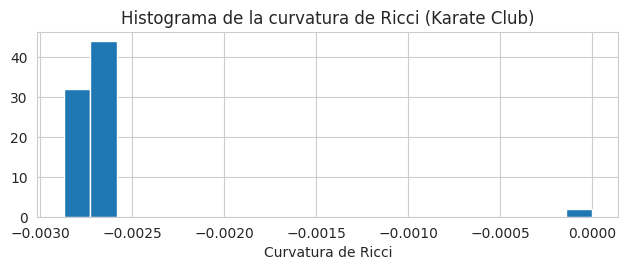

In [38]:
show_results(G_rf)

Después del flujo de Ricci, los pesos de las aristas (métricas de flujo de Ricci) cambiaron y las curvaturas de Ricci de las aristas convergieron a $-0.0115$.

# [Detección de comunidades con flujo de Olivier Ricci](https://arxiv.org/pdf/1907.03993)



La clave de la curvatura de Ollivier-Ricci es el transporte óptimo. El ejemplo anterior demuestra el resultado del flujo de Ricci con la configuración de distribución de probabilidad de Lin y Yau para el transporte óptimo, la cual distribuye las probabilidades uniformemente hacia los vecinos. Para el nodo $x$ y su conjunto de vecinos $\pi(x)$, definen la distribución de probabilidad con $\alpha\in[0,1]$ de la siguiente manera:

$$m^{\alpha}_x(x_i)= \begin{cases} \alpha & \text{ si } x_i = x\\ \frac{1-\alpha}{|\pi(x)|} & \text{ si } x_i \in \pi(x)\\ 0 & \text{ en otro caso } \end{cases}$$

Propusimos una configuración más generalizada de distribuciones de probabilidad como la siguiente, donde

$C=\sum_{x_i \in \pi(x)} b^{-d(x,x_i)^p}$:$$m^{\alpha,p}_x(x_i)= \begin{cases} \alpha & \text{ si } x_i = x\\ \frac{1-\alpha}{C}\cdot  b^{-d(x,x_i)^p} & \text{ si } x_i \in \pi(x)\\ 0 & \text{ en otro caso } \end{cases}$$

Esta configuración nos permite modificar la distribución de probabilidad influenciada por el peso de la arista y obtener un mejor resultado para la detección de comunidades. Si tomamos $p=0$, entonces la distribución vuelve a la configuración de Lin y Yau; si establecemos $b=\exp$ y $p=2$, entonces esta distribución es similar a la "difusión de calor" (heat diffusion).

Resulta que, en la mayoría de los casos, $(b,p)=(\exp,1)$ y $(b,p)=(\exp,2)$ tienen el mejor desempeño para la detección de comunidades.

Parámetros

- alpha: El parámetro para la distribución de probabilidad, en el rango [0 ~ 1]. Significa la proporción de masa que se queda en el nodo original.

- base: Variable base para la distribución de pesos. Por defecto `math.e`

- exp_power: Potencia exponencial para la distribución de pesos. Por defecto: `0`

- method: Método de transporte. ["OTD", "ATD", "Sinkhorn"]. Por defecto:

  * Sinkhorn"OTD" para Distancia de Transporte Óptimo (Optimal Transportation Distance).
  * "ATD" para Distancia de Transporte Promedio (Average Transportation Distance).
  * "Sinkhorn" para la distancia OTD aproximada por Sinkhorn (más rápida).

In [40]:
import math

In [41]:
orf2 = OllivierRicci(G, alpha=0.5, base=math.e, exp_power=1, verbose="ERROR")
orf2.compute_ricci_flow(iterations=50)
G_rf2 = orf2.G.copy()

Red del Karate Club, primeros 5 enlaces: 
La curvatura de Ricci del enlace (0,1) es -0.019349
La curvatura de Ricci del enlace (0,2) es -0.001516
La curvatura de Ricci del enlace (0,3) es -0.010322
La curvatura de Ricci del enlace (0,4) es -0.001809
La curvatura de Ricci del enlace (0,5) es -0.002310


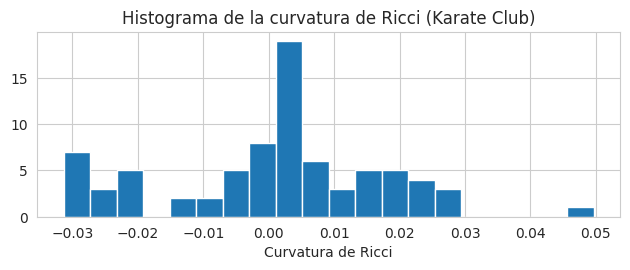

In [42]:
show_results(G_rf2)

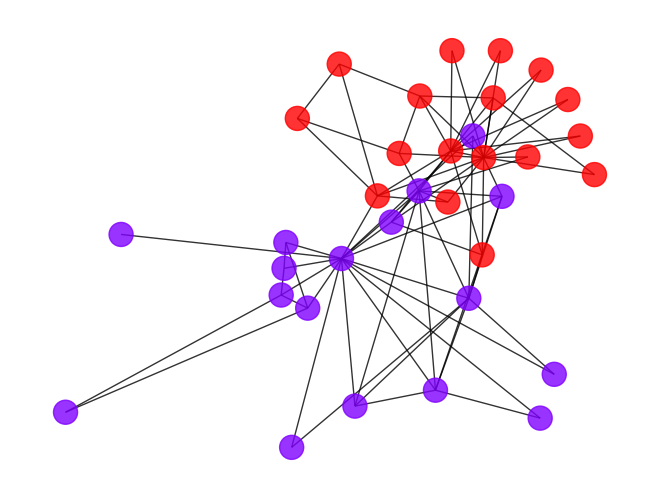

In [52]:
def draw_graph(G, clustering_label="club"):
    """
    A helper function to draw a nx graph with community.
    """
    complex_list = nx.get_node_attributes(G, clustering_label)

    le = preprocessing.LabelEncoder()
    node_color = le.fit_transform(list(complex_list.values()))

    nx.draw_spring(G, nodelist=G.nodes(),
                   node_color=node_color,
                   cmap=plt.cm.rainbow,
                   alpha=0.8)

draw_graph(G_rf2)

In [12]:
#@title Detección de comunidades con Olivier Ricci
%%html
<iframe width="560" height="315" src="https://www.youtube.com/embed/QlENb_XlJ_8?si=TPdQkVg5r8qK8chx" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>